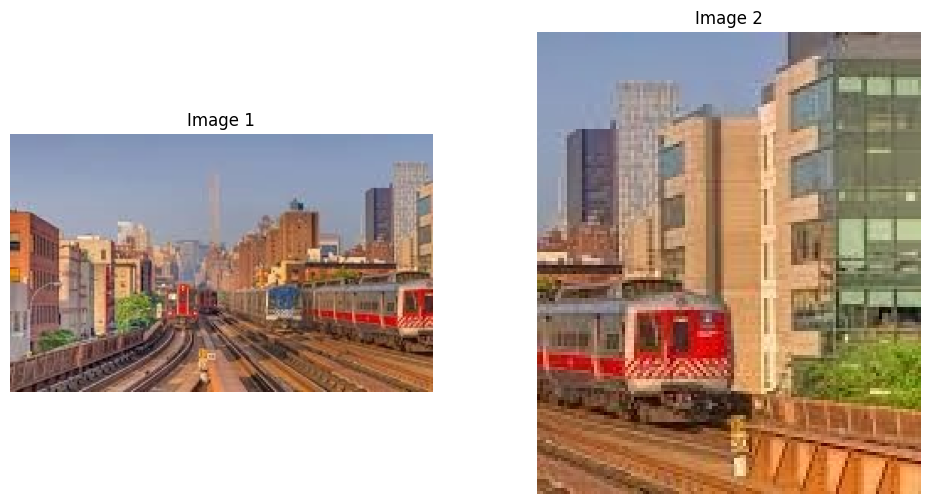

# keypoints in image 1: 405
# keypoints in image 2: 221


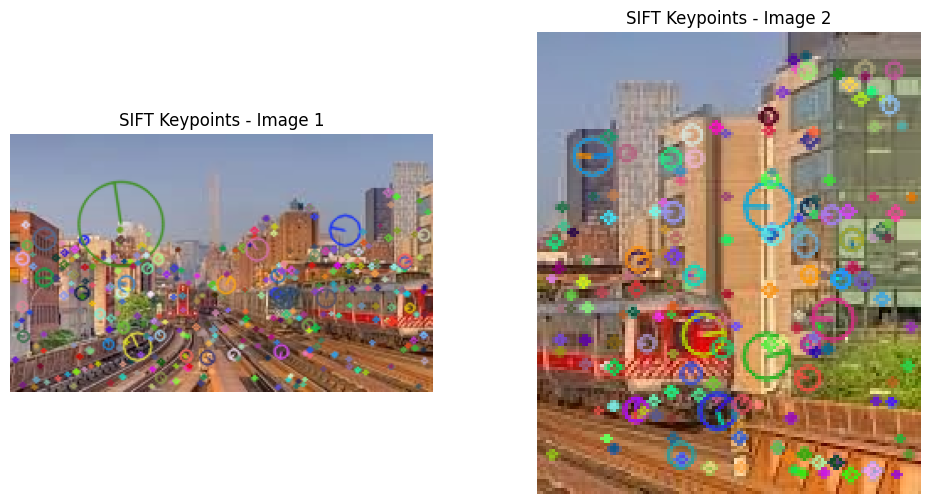

# good matches after ratio test: 56


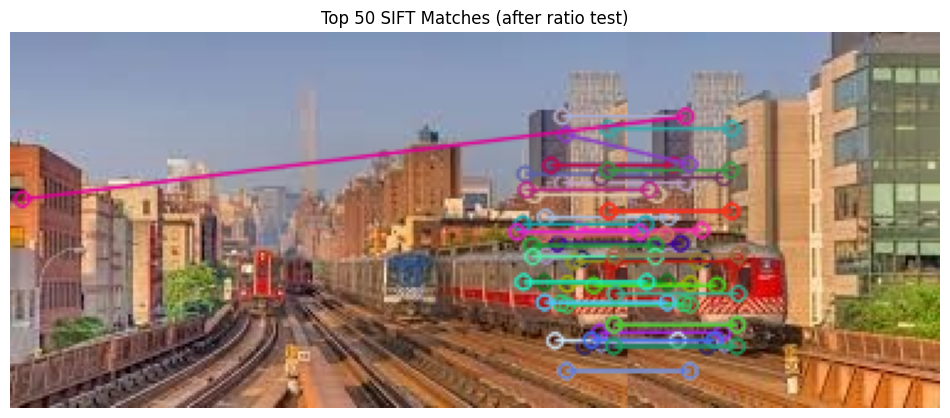

Homography matrix H:
[[ 9.96435595e-01  1.21155887e-04  2.01046107e+02]
 [-8.59938799e-04  9.99987482e-01  1.08390990e-02]
 [-1.13121016e-05  1.63773009e-06  1.00000000e+00]]


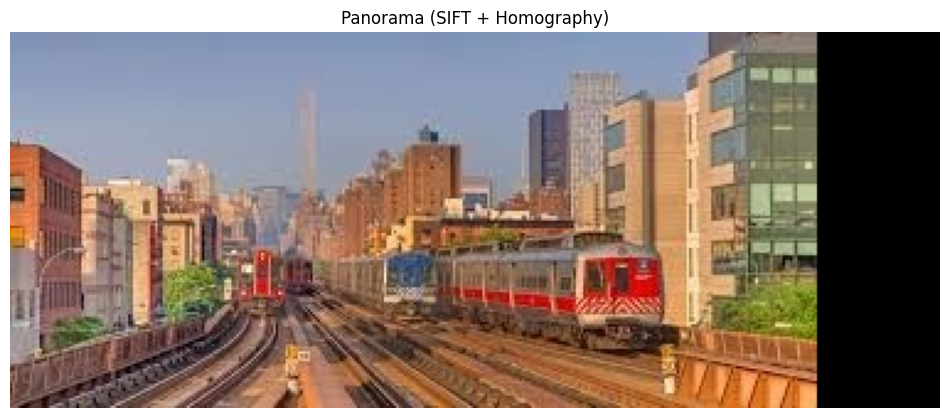

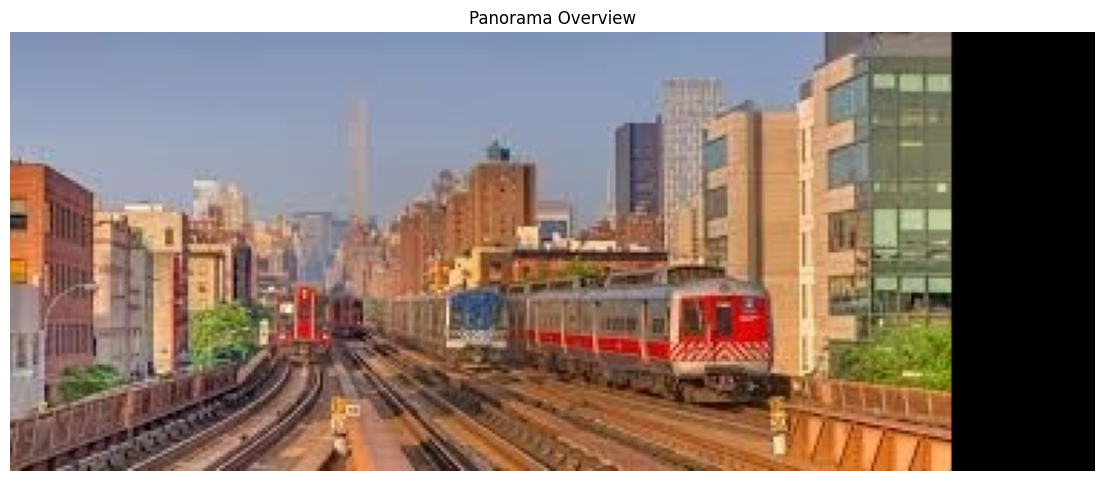

In [11]:
# SIFT
# ==== 0. Setup: Install & Import ====
# If you're in Colab, uncomment this line if SIFT is not available
# !pip install opencv-contrib-python

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Show images nicely in notebook
plt.rcParams["figure.figsize"] = (12, 6)
# ==== 1. Load Images ====
# Put your images in Colab (e.g., upload to /content)
# Make sure they have overlapping regions

img1_path = "C:/Users/LUCUS/Desktop/japan-data/Kanazawa University Realated/Computer vision/content/images1b.jpg"  # left (base) image
img2_path = "C:/Users/LUCUS/Desktop/japan-data/Kanazawa University Realated/Computer vision/content/images2b.jpg"  # right (to be warped) image

img1_color = cv2.imread(img1_path)
img2_color = cv2.imread(img2_path)

if img1_color is None or img2_color is None:
    raise FileNotFoundError("Check img1_path / img2_path — image not found.")

# Convert BGR (OpenCV) to RGB (matplotlib)
img1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2RGB)

plt.subplot(1, 2, 1); plt.imshow(img1); plt.title("Image 1"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(img2); plt.title("Image 2"); plt.axis("off")
plt.show()

# ==== 2. SIFT Feature Detection & Description ====

# Use grayscale for SIFT
gray1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

# Create SIFT detector (new OpenCV)
try:
    sift = cv2.SIFT_create()
except:
    # Fallback for older OpenCV with contrib
    sift = cv2.xfeatures2d.SIFT_create()

# Detect keypoints and compute descriptors
kps1, des1 = sift.detectAndCompute(gray1, None)
kps2, des2 = sift.detectAndCompute(gray2, None)

print(f"# keypoints in image 1: {len(kps1)}")
print(f"# keypoints in image 2: {len(kps2)}")

# Visualize keypoints (just for report)
img1_kp = cv2.drawKeypoints(img1, kps1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_kp = cv2.drawKeypoints(img2, kps2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.subplot(1, 2, 1); plt.imshow(img1_kp); plt.title("SIFT Keypoints - Image 1"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(img2_kp); plt.title("SIFT Keypoints - Image 2"); plt.axis("off")
plt.show()

# ==== 3. Descriptor Matching with Lowe's Ratio Test ====

# FLANN parameters for SIFT (uses L2 distance)
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)

# kNN match: each descriptor in des1 → 2 nearest neighbors in des2
matches_knn = flann.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good_matches = []
ratio_thresh = 0.75

for m, n in matches_knn:
    if m.distance < ratio_thresh * n.distance:
        good_matches.append(m)

print(f"# good matches after ratio test: {len(good_matches)}")

# Visualize top N matches
N_SHOW = 50
img_matches = cv2.drawMatches(
    img1_color, kps1,
    img2_color, kps2,
    sorted(good_matches, key=lambda x: x.distance)[:N_SHOW],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f"Top {N_SHOW} SIFT Matches (after ratio test)")
plt.axis("off")
plt.show()

# ==== 4. Homography Estimation ====

if len(good_matches) < 4:
    raise ValueError("Not enough matches to estimate homography!")

# Extract matched keypoint coordinates
src_pts = np.float32([kps1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kps2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# Compute homography: img2 → img1
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

print("Homography matrix H:")
print(H)

# Inlier mask (for visualization / debugging)
matches_mask = mask.ravel().tolist()

# ==== 5. Warp Image 2 → Image 1 Coordinate System ====

h1, w1 = img1_color.shape[:2]
h2, w2 = img2_color.shape[:2]

# Warp img2 into the panorama space
# Width: enough to hold both images side-by-side
# Height: max of the two heights
panorama_width = w1 + w2
panorama_height = max(h1, h2)

warped_img2 = cv2.warpPerspective(img2_color, H, (panorama_width, panorama_height))

# Place img1 into the panorama canvas
panorama = warped_img2.copy()
panorama[0:h1, 0:w1] = img1_color

plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title("Panorama (SIFT + Homography)")
plt.axis("off")
plt.show()

# ==== 6. Optional: Simple Overlap Visualization ====

# Convert panorama to RGB for visualization
panorama_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.imshow(panorama_rgb)
plt.title("Panorama Overview")
plt.axis("off")
plt.show()




[ORB] # keypoints in image 1: 1108
[ORB] # keypoints in image 2: 272


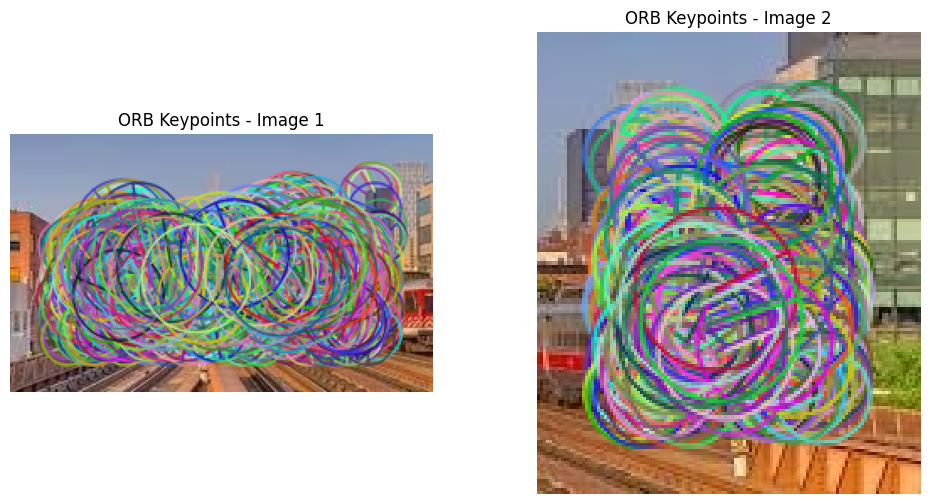

[ORB] # good matches after ratio test: 469


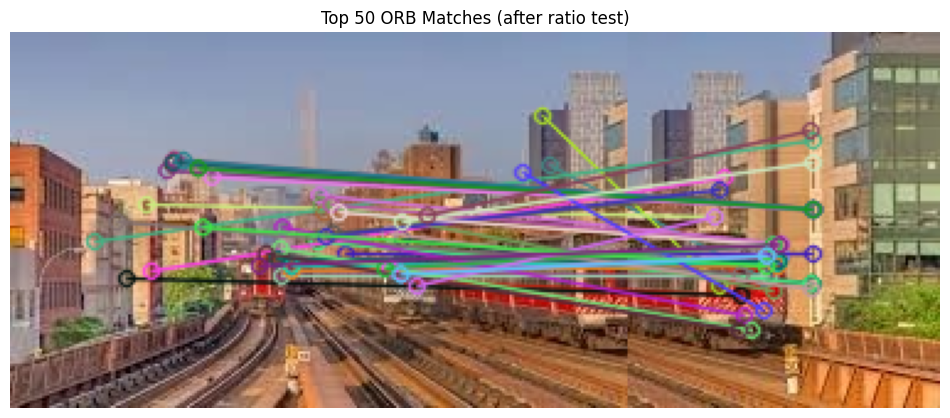

[ORB] Homography matrix H_orb:
[[-6.57835333e-01  3.40235721e-01  3.12076430e+01]
 [-9.72992555e-01  1.82483182e-01  6.44328714e+01]
 [-1.30396211e-02  8.46021637e-04  1.00000000e+00]]


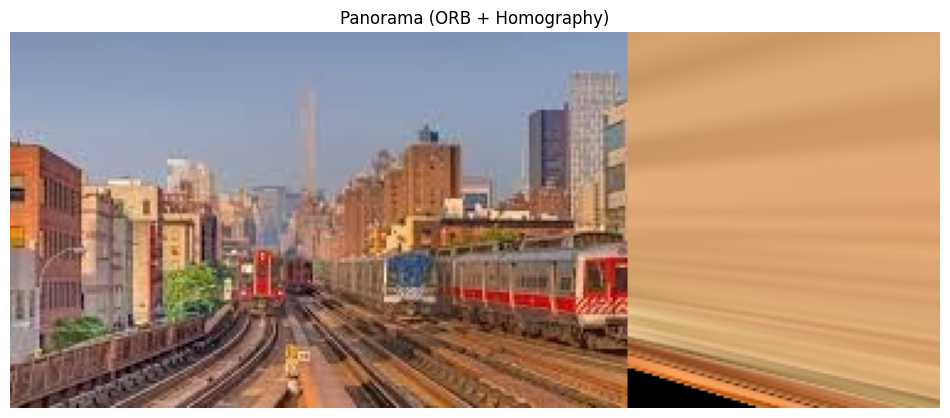

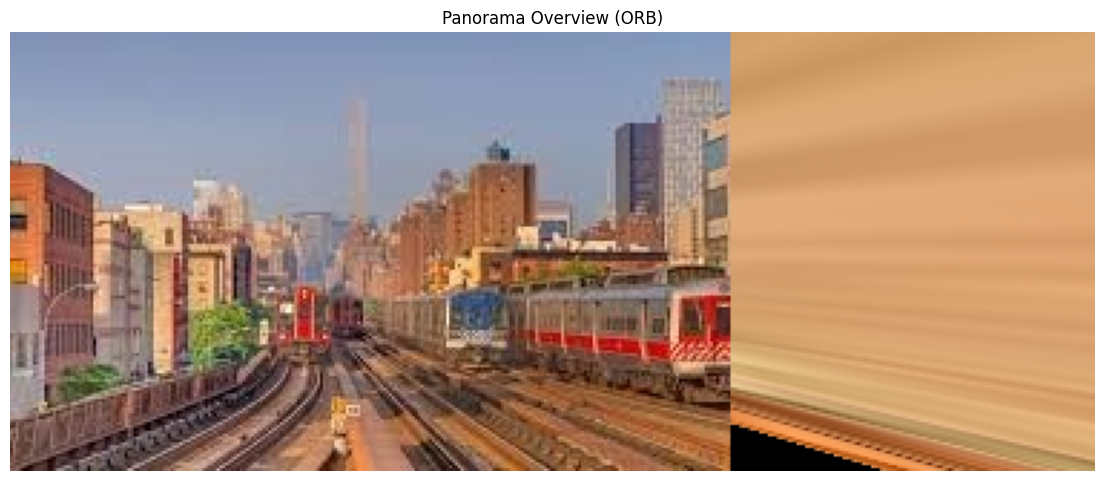

In [18]:
# ORB
# ==== 2. ORB Feature Detection & Description ====

# Use grayscale for ORB
gray1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

# Create ORB detector
orb = cv2.ORB_create(100000)  # 5000 keypoints max (you can change this)

# Detect keypoints and compute descriptors
kps1_orb, des1_orb = orb.detectAndCompute(gray1, None)
kps2_orb, des2_orb = orb.detectAndCompute(gray2, None)

print(f"[ORB] # keypoints in image 1: {len(kps1_orb)}")
print(f"[ORB] # keypoints in image 2: {len(kps2_orb)}")

# Visualize keypoints (just for report)
img1_kp_orb = cv2.drawKeypoints(
    img1, kps1_orb, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)
img2_kp_orb = cv2.drawKeypoints(
    img2, kps2_orb, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.subplot(1, 2, 1); plt.imshow(img1_kp_orb); plt.title("ORB Keypoints - Image 1"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(img2_kp_orb); plt.title("ORB Keypoints - Image 2"); plt.axis("off")
plt.show()

# ==== 3. Descriptor Matching with Lowe's Ratio Test (ORB) ====

# ORB uses binary descriptors → Hamming distance + BFMatcher
bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

# kNN match: each descriptor in des1_orb → 2 nearest neighbors in des2_orb
matches_knn_orb = bf_orb.knnMatch(des1_orb, des2_orb, k=2)

# Lowe's ratio test
good_matches_orb = []
ratio_thresh = 0.95

for m, n in matches_knn_orb:
    if m.distance < ratio_thresh * n.distance:
        good_matches_orb.append(m)

print(f"[ORB] # good matches after ratio test: {len(good_matches_orb)}")

# Visualize top N matches
N_SHOW = 50
img_matches_orb = cv2.drawMatches(
    img1_color, kps1_orb,
    img2_color, kps2_orb,
    sorted(good_matches_orb, key=lambda x: x.distance)[:N_SHOW],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.imshow(cv2.cvtColor(img_matches_orb, cv2.COLOR_BGR2RGB))
plt.title(f"Top {N_SHOW} ORB Matches (after ratio test)")
plt.axis("off")
plt.show()

# ==== 4. Homography Estimation (ORB) ====

if len(good_matches_orb) < 4:
    raise ValueError("[ORB] Not enough matches to estimate homography!")

# Extract matched keypoint coordinates
src_pts_orb = np.float32(
    [kps1_orb[m.queryIdx].pt for m in good_matches_orb]
).reshape(-1, 1, 2)
dst_pts_orb = np.float32(
    [kps2_orb[m.trainIdx].pt for m in good_matches_orb]
).reshape(-1, 1, 2)

# Compute homography: img2 → img1
H_orb, mask_orb = cv2.findHomography(dst_pts_orb, src_pts_orb, cv2.RANSAC, 5.0)

print("[ORB] Homography matrix H_orb:")
print(H_orb)

# Inlier mask (for visualization / debugging)
matches_mask_orb = mask_orb.ravel().tolist()

# ==== 5. Warp Image 2 → Image 1 Coordinate System (ORB) ====

h1, w1 = img1_color.shape[:2]
h2, w2 = img2_color.shape[:2]

# Warp img2 into the panorama space
panorama_width = w1 + w2
panorama_height = max(h1, h2)

warped_img2_orb = cv2.warpPerspective(img2_color, H_orb, (panorama_width, panorama_height))

# Place img1 into the panorama canvas
panorama_orb = warped_img2_orb.copy()
panorama_orb[0:h1, 0:w1] = img1_color

plt.imshow(cv2.cvtColor(panorama_orb, cv2.COLOR_BGR2RGB))
plt.title("Panorama (ORB + Homography)")
plt.axis("off")
plt.show()

# ==== 6. Optional: Simple Overlap Visualization (ORB) ====

panorama_orb_rgb = cv2.cvtColor(panorama_orb, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.imshow(panorama_orb_rgb)
plt.title("Panorama Overview (ORB)")
plt.axis("off")
plt.show()


In [19]:
# ==== 7. ML comparison between SIFT and ORB ====

def compute_metrics(kps1, kps2, good_matches, H, src_pts, dst_pts, mask, name="METHOD"):
    """Compute quantitative stitching metrics for one method."""
    num_kp1 = len(kps1)
    num_kp2 = len(kps2)
    num_good = len(good_matches)
    mean_dist = float(np.mean([m.distance for m in good_matches])) if good_matches else np.inf

    # Inlier mask from RANSAC
    inlier_mask = mask.ravel().astype(bool)
    num_inliers = int(inlier_mask.sum())
    inlier_ratio = num_inliers / max(num_good, 1)

    # Reprojection error: project dst -> src using H
    if num_inliers > 0:
        src_inlier = src_pts[inlier_mask].reshape(-1, 2)
        dst_inlier = dst_pts[inlier_mask]
        dst_proj = cv2.perspectiveTransform(dst_inlier, H).reshape(-1, 2)
        reproj_error = float(
            np.mean(np.linalg.norm(src_inlier - dst_proj, axis=1))
        )
    else:
        reproj_error = np.inf

    metrics = {
        "num_kp1": num_kp1,
        "num_kp2": num_k2 if (num_k2 := num_kp2) else num_kp2,  # keep name explicit
        "num_good": num_good,
        "num_inliers": num_inliers,
        "inlier_ratio": inlier_ratio,
        "mean_distance": mean_dist,
        "reproj_error": reproj_error,
    }

    print(f"\n[{name}] metrics")
    for k, v in metrics.items():
        print(f"  {k}: {v}")

    return metrics


# --- compute metrics for SIFT ---
metrics_sift = compute_metrics(
    kps1, kps2,
    good_matches,
    H,
    src_pts, dst_pts,
    mask,
    name="SIFT"
)

# --- compute metrics for ORB ---
metrics_orb = compute_metrics(
    kps1_orb, kps2_orb,
    good_matches_orb,
    H_orb,
    src_pts_orb, dst_pts_orb,
    mask_orb,
    name="ORB"
)

# ==== 8. K-means (unsupervised ML) on the metrics ====

# Build feature vectors for each method
# Note: we negate distances/errors so that "bigger is better" for every feature.
feat_sift = np.array([
    metrics_sift["num_good"],
    metrics_sift["inlier_ratio"],
    -metrics_sift["mean_distance"],
    -metrics_sift["reproj_error"],
], dtype=np.float32)

feat_orb = np.array([
    metrics_orb["num_good"],
    metrics_orb["inlier_ratio"],
    -metrics_orb["mean_distance"],
    -metrics_orb["reproj_error"],
], dtype=np.float32)

X = np.vstack([feat_sift, feat_orb])  # shape (2, 4)

# Normalize features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-6
X_norm = (X - X_mean) / X_std

# K-means with K=2 (2 “performance types”)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
K = 2
attempts = 10

compactness, labels, centers = cv2.kmeans(
    X_norm.astype(np.float32),
    K,
    None,
    criteria,
    attempts,
    cv2.KMEANS_RANDOM_CENTERS,
)

labels = labels.flatten()
print("\n=== ML comparison with K-means ===")
print("Feature order: [num_good, inlier_ratio, -mean_dist, -reproj_error]")
print("Cluster centers (normalized space):")
print(centers)

print(f"\nSIFT is in cluster: {labels[0]}")
print(f"ORB  is in cluster: {labels[1]}")

# Decide which cluster is “better”: sum of center (bigger = more good matches,
# higher inlier ratio, smaller distance/error because we negated them)
cluster_scores = centers.sum(axis=1)
best_cluster = int(np.argmax(cluster_scores))

if labels[0] == best_cluster:
    better = "SIFT"
else:
    better = "ORB"

print(f"\nAccording to K-means on these metrics, **{better}** "
      f"has the better performance profile for this image pair.")


[SIFT] metrics
  num_kp1: 405
  num_kp2: 221
  num_good: 56
  num_inliers: 50
  inlier_ratio: 0.8928571428571429
  mean_distance: 67.23855545691082
  reproj_error: 0.06354257464408875

[ORB] metrics
  num_kp1: 1108
  num_kp2: 272
  num_good: 469
  num_inliers: 20
  inlier_ratio: 0.042643923240938165
  mean_distance: 70.5948827292111
  reproj_error: 1.564269781112671

=== ML comparison with K-means ===
Feature order: [num_good, inlier_ratio, -mean_dist, -reproj_error]
Cluster centers (normalized space):
[[-1.         0.9999977  0.9999994  0.9999986]
 [ 1.        -0.9999976 -0.9999994 -0.9999986]]

SIFT is in cluster: 0
ORB  is in cluster: 1

According to K-means on these metrics, **SIFT** has the better performance profile for this image pair.
